In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from syssimx_examples.controlled_pendulum.components import FEMPendulum, OpenSimPendulum  
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config              

In [13]:
master = FEMPendulum("Master")
master.initialize(0.0)
master._use_gravity = True
master._with_contact = False

model = OpenSimPendulum()
model._use_gravity = master._use_gravity
model._with_contact = master._with_contact

total_inertia = master.inertia
mass = master.mass
length = master._equivalent_length
inertia = total_inertia - mass * (length**2)

model.parameters["Model"]["inertia"] = inertia
model.parameters["Model"]["mass"] = mass
model.parameters["Model"]["length"] = length

model.parameters["InitialConditions"]["theta_start"] = 0.3
model.parameters["InitialConditions"]["omega_start"] = 0
model.parameters["InitialConditions"]["tau"] = 1

model.initialize(0.0)

In [14]:
from syssimx import System, EventConnection

def wall_contact_event_indicator(model: OpenSimPendulum) -> float:
    return model.get_outputs()["theta"].magnitude - np.deg2rad(0)

model.add_event_indicator(
    name="wall_hit", func=wall_contact_event_indicator, direction=-1
)

system = System(name="OpenSim Pendulum_System")
system.add_component(model)

event_connection = EventConnection(
    src_comp=model.name,
    src_port='wall_hit',
    dst_comp=model.name,
    dst_port=model.input_specs["omega_invert"].name,
)
system.add_event_connection(event_connection)
system.initialize(0.0)

In [15]:
t_start = 0.0
t_end = 1.0
dt = 0.01  # Macro step size

system.run(t0=t_start, tf=t_end, dt=dt)

[INFO] [Hybrid] Time: 0.0100 s
[INFO] [Hybrid] Time: 0.0200 s
[INFO] [Hybrid] Time: 0.0300 s
[INFO] [Hybrid] Time: 0.0400 s
[INFO] [Hybrid] Time: 0.0500 s
[INFO] [Hybrid] Time: 0.0600 s
[INFO] [Hybrid] Time: 0.0700 s
[INFO] [Hybrid] Time: 0.0800 s
[INFO] [Hybrid] Time: 0.0900 s
[INFO] [Hybrid] Time: 0.1000 s
[INFO] [Hybrid] Time: 0.1100 s
[INFO] [Hybrid] Time: 0.1200 s
[INFO] [Hybrid] Time: 0.1300 s
[INFO] [Hybrid] Time: 0.1400 s
[INFO] [Hybrid] Time: 0.1500 s
[INFO] [Hybrid] Time: 0.1600 s
[INFO] [Hybrid] Time: 0.1700 s
[INFO] [Hybrid] Time: 0.1800 s
[INFO] [Hybrid] Time: 0.1900 s
[INFO] [Hybrid] Time: 0.2000 s
[INFO] [Hybrid] Time: 0.2100 s
[INFO] [Hybrid] Time: 0.2200 s
[INFO] [Hybrid] Time: 0.2300 s
[INFO] [Hybrid] Time: 0.2400 s
[INFO] ========================================================================
[INFO] [Hybrid] Events detected in interval [0.23000000, 0.24000000]
[INFO] ========================================================================
[INFO] [Hybrid] Crossings: 

In [16]:
# 7) Extract and plot results
history = system.get_history()
pendulum_history = history["opensim_pendulum"]
event_history = history["Events"]

t_vals, data = pendulum_history
q_vals = data["theta"]
omega_vals = data["omega"]
alpha_vals = data["alpha"]

# Get event times
event_times = event_history.get(("opensim_pendulum", "wall_hit"), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event:
    print(f"First event at t = {t_event.t:.8f} s")


Detected 2 events
First event at t = 0.23899292 s


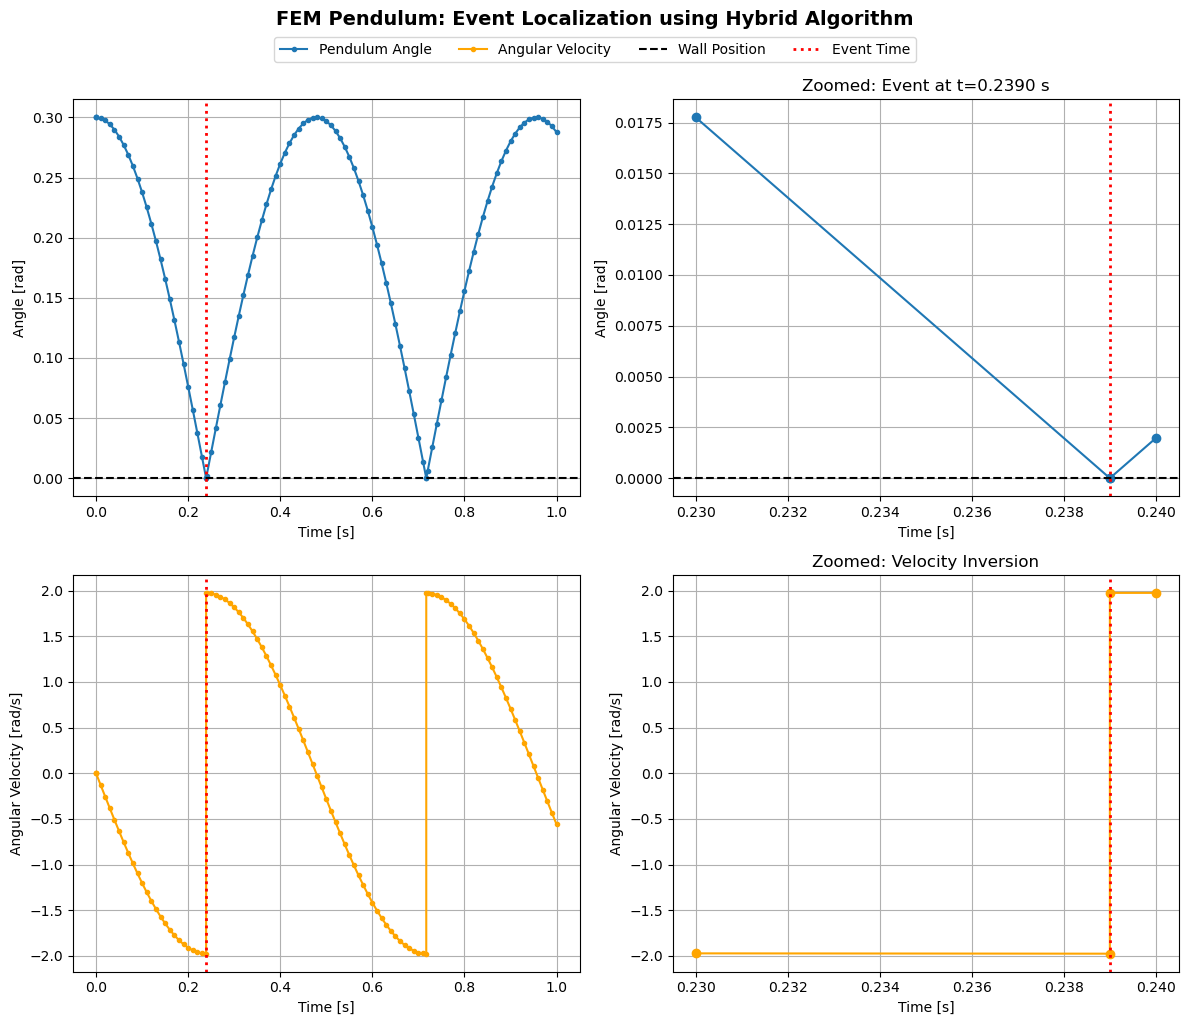

In [17]:
# 8) Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "FEM Pendulum: Event Localization using Hybrid Algorithm",
    fontweight="bold",
    fontsize=14,
    y=1.02,
)

# Top left: Full angle trajectory
(line1,) = axs[0, 0].plot(t_vals, q_vals, label="Pendulum Angle", marker="o", markersize=3)
line2 = axs[0, 0].axhline(0, color="k", linestyle="--", label="Wall Position")
if t_event:
    line3 = axs[0, 0].axvline(
        t_event.t, color="red", linestyle=":", linewidth=2, label="Event Time"
    )
axs[0, 0].set_xlabel("Time [s]")
axs[0, 0].set_ylabel("Angle [rad]")
axs[0, 0].grid()

# Top right: Zoomed angle near event
if t_event:
    zoom_window = 0.01
    mask = (t_vals >= t_event.t - zoom_window) & (t_vals <= t_event.t + zoom_window)
    axs[0, 1].plot(t_vals[mask], q_vals[mask], "o-", markersize=6)
    axs[0, 1].axhline(0, color="k", linestyle="--")
    axs[0, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[0, 1].set_xlabel("Time [s]")
    axs[0, 1].set_ylabel("Angle [rad]")
    axs[0, 1].set_title(f"Zoomed: Event at t={t_event.t:.4f} s")
    axs[0, 1].grid()

# Bottom left: Full angular velocity
(line4,) = axs[1, 0].plot(
    t_vals, omega_vals, color="orange", label="Angular Velocity", marker="o", markersize=3
)

if t_event:
    axs[1, 0].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
axs[1, 0].set_xlabel("Time [s]")
axs[1, 0].set_ylabel("Angular Velocity [rad/s]")
axs[1, 0].grid()

# Bottom right: Zoomed velocity near event
if t_event:
    axs[1, 1].plot(t_vals[mask], omega_vals[mask], "o-", color="orange", markersize=6)
    axs[1, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[1, 1].set_xlabel("Time [s]")
    axs[1, 1].set_ylabel("Angular Velocity [rad/s]")
    axs[1, 1].set_title("Zoomed: Velocity Inversion")
    axs[1, 1].grid()

signals = [line1, line4, line2, line3]  # , line5]
labels = [s.get_label() for s in signals if s is not None]
fig.legend(signals, labels, loc="upper center", bbox_to_anchor=(0.5, 1), ncol=5)

plt.tight_layout()
#plt.savefig("../figures/Hybrid/test_2_location_FEM.svg")
plt.show()